In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"asmaulhusnaankhy","key":"4fcd096627d5e2a020d9d25664c77af4"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s cats

ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset                 Cats-vs-Dogs                                         825979578  2020-03-12 05:34:30.730000         108995        977  0.875            
marquis03/cats-and-dogs                                    Cats and Dogs                                         10219362  2023-10-27 10:48:19.220000          17324        147  1                
waqi786/cats-dataset                                       🐾 Cats Dataset                                            5654  2024-07-31 06:12:49.530000           7173        103  1                
chetankv/dogs-cats-images

In [ ]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q microsoft-catsvsdogs-dataset.zip

replace MSR-LA - 3467.docx? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Import Libraries:
=

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

Detecting the Bad Files:
=

In [ ]:
import os

bad_files = []

for root, dirs, files , in os.walk("/content/PetImages"):
  for file in files:
    path = os.path.join(root, file)
    try:
      img = tf.io.read_file(path)
      tf.io.decode_image(img)
    except:
        bad_files.append(path)

print(len(bad_files))
print(bad_files)

0
[]


Deleting the Bad Files:
=

In [ ]:
for file in bad_files:
  os.remove(file)

print("Deleted : ", len(bad_files), 'corrupted files')

Deleted :  0 corrupted files


Load Dataset:
=

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    "/content/PetImages",
    validation_split = 0.2,
    subset = 'training',
    seed = 123,
    image_size = (150, 150),
    batch_size = 32
)

validation_ds = keras.utils.image_dataset_from_directory(
    '/content/PetImages',
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = (150, 150),
    batch_size = 32
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


Normalization:
=

In [ ]:
def process (image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

ImageDataGenerator With Data Augmentation:
=

In [ ]:

data_augmentation = keras.Sequential([
     keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomContrast(0.1)]

)

Prefetch:
=

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)

Load VGG16:
=

In [ ]:
conv_base = VGG16(
    include_top = False,
    weights = 'imagenet',
    input_shape = (150, 150, 3)
)
conv_base.trainable = False

In [ ]:
model = Sequential([
    Input(shape = (150, 150, 3)),
    data_augmentation,
    conv_base,
    Flatten(),
    #GlobalAveragePooling2D(),
    Dense(256, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

Compile:
=

In [ ]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

Train:
=

In [ ]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True)

history = model.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 112ms/step - accuracy: 0.8337 - loss: 0.3701 - val_accuracy: 0.9052 - val_loss: 0.2225
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.8645 - loss: 0.3034 - val_accuracy: 0.9130 - val_loss: 0.2114
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.8748 - loss: 0.2861 - val_accuracy: 0.9100 - val_loss: 0.2128
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.8779 - loss: 0.2768 - val_accuracy: 0.9034 - val_loss: 0.2202
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.8788 - loss: 0.2729 - val_accuracy: 0.8978 - val_loss: 0.2279
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.8826 - loss: 0.2649 - val_accuracy: 0.8994 - val_loss: 0.2335
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.8889 - loss: 0.2565 - val_accuracy: 0.9128 - val_loss: 0.2053
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.8900 - loss: 0

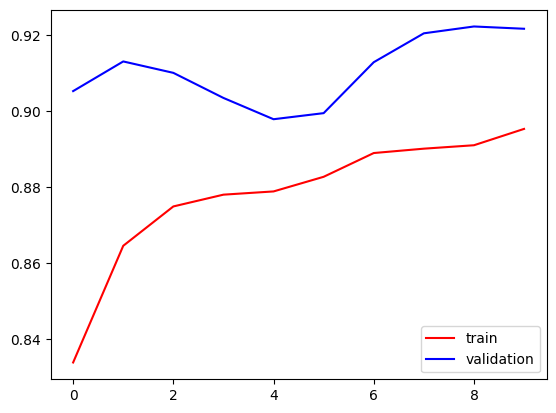

In [ ]:
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

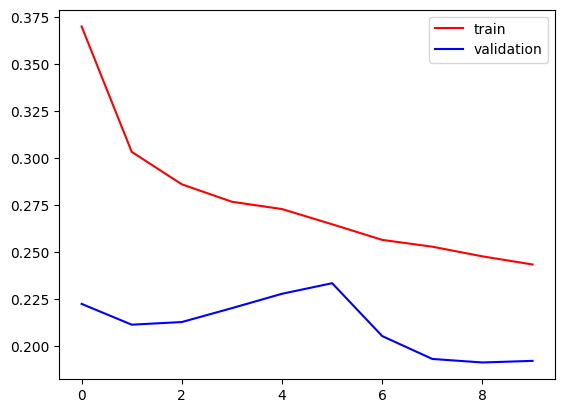

In [ ]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()